# Análise exploratória da série temporal de tráfego do PTT/IX

Este notebook foi adaptado para:

- trabalhar **apenas com o tráfego total** (`entrada + saída`);
- realizar as análises **somente após o filtro de completude anual**;
- expressar os resultados em **Gbps**;
- gerar resumos anuais em Gbps;
- plotar a série temporal total com **média diária** e **intervalo de confiança de 95%**;
- analisar o comportamento por **dia da semana**;
- comparar **dias úteis** com **fim de semana**.

## 1. Importação de bibliotecas

In [60]:
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Caminhos dos arquivos

Ajuste esta célula conforme a estrutura do seu projeto.

Se o notebook estiver em `monograph/notebooks` e a pasta `data` estiver em `monograph/data`, então `Path.cwd().parent` costuma ser suficiente.

In [61]:
base_dir = Path.cwd().parent  # ajuste se necessário

arquivo_xml = base_dir / "data" / "raw" / "ptt.xml"
saida_dir = base_dir / "data" / "processed"

arquivo_serie_csv = saida_dir / "serie_temporal_filtrada_gbps.csv"
arquivo_resumo_csv = saida_dir / "resumo_anual_filtrado_gbps.csv"
arquivo_weekday_csv = saida_dir / "resumo_weekday_gbps.csv"
arquivo_weekend_csv = saida_dir / "comparacao_weekend_gbps.csv"

saida_dir.mkdir(parents=True, exist_ok=True)

print("Base dir:", base_dir)
print("XML:", arquivo_xml)
print("Existe?", arquivo_xml.exists())
print("Saída:", saida_dir)

Base dir: /Users/cristiane/git/mba-ai-usp/monograph
XML: /Users/cristiane/git/mba-ai-usp/monograph/data/raw/ptt.xml
Existe? True
Saída: /Users/cristiane/git/mba-ai-usp/monograph/data/processed


## 3. Leitura do arquivo XML

In [62]:
tree = ET.parse(arquivo_xml)
root = tree.getroot()

step = int(root.find("step").text)
lastupdate = int(root.find("lastupdate").text)
rows = root.find("rra/database").findall("row")

print("step (segundos):", step)
print("lastupdate:", lastupdate)
print("número de linhas:", len(rows))

step (segundos): 300
lastupdate: 1768334849
número de linhas: 2100154


## 4. Funções auxiliares

In [63]:
def parse_valor(texto):
    if texto is None or texto == "NaN":
        return None
    return float(texto)

def medicoes_esperadas_no_ano(ano, passo_segundos=300):
    dias = 366 if calendar.isleap(ano) else 365
    return (24 * 60 * 60 // passo_segundos) * dias

## 5. Reconstrução da série temporal

Cada linha do XML possui dois valores (`v`), correspondentes aos fluxos de entrada e saída.

Neste notebook, a variável principal de análise será:

`total_bps = entrada + saída`

In [64]:
n = len(rows)
start_time = lastupdate - (n * step)

serie = []

for i, row in enumerate(rows):
    timestamp = start_time + i * step
    datahora = datetime.fromtimestamp(timestamp)

    vals = row.findall("v")

    v0 = parse_valor(vals[0].text) if len(vals) > 0 else None
    v1 = parse_valor(vals[1].text) if len(vals) > 1 else None

    total = None if (v0 is None or v1 is None) else (v0 + v1)

    serie.append((datahora, total))

df = pd.DataFrame(serie, columns=["datahora", "total_bps"])
df["datahora"] = pd.to_datetime(df["datahora"])
df["year"] = df["datahora"].dt.year

df.head()

,datahora,total_bps,year
0,2006-01-26 13:17:29,NaN,2006
1,2006-01-26 13:22:29,NaN,2006
2,2006-01-26 13:27:29,NaN,2006
3,2006-01-26 13:32:29,NaN,2006
4,2006-01-26 13:37:29,NaN,2006


## 6. Verificação inicial

In [65]:
print(df.head())
print()
print(df.info())
print()
print("Período coberto:")
print(df["datahora"].min(), "até", df["datahora"].max())
print()
print("NaN em total_bps:", df["total_bps"].isna().sum())

             datahora  total_bps  year
0 2006-01-26 13:17:29        NaN  2006
1 2006-01-26 13:22:29        NaN  2006
2 2006-01-26 13:27:29        NaN  2006
3 2006-01-26 13:32:29        NaN  2006
4 2006-01-26 13:37:29        NaN  2006

<class 'pandas.DataFrame'>
RangeIndex: 2100154 entries, 0 to 2100153
Data columns (total 3 columns):
 #   Column     Dtype         
---  ------     -----         
 0   datahora   datetime64[us]
 1   total_bps  float64       
 2   year       int32         
dtypes: datetime64[us](1), float64(1), int32(1)
memory usage: 40.1 MB
None

Período coberto:
2006-01-26 13:17:29 até 2026-01-13 17:02:29

NaN em total_bps: 217539


## 7. Resumo de completude anual

A completude anual é calculada com base em `total_bps`, comparando o número esperado de medições com o número de valores ausentes.

In [66]:
resumo_completude = df.groupby("year").agg(
    total_linhas=("total_bps", "size"),
    n_na_total=("total_bps", lambda x: x.isna().sum())
)

resumo_completude["esperado"] = resumo_completude.index.map(medicoes_esperadas_no_ano)
resumo_completude["completude"] = 1 - (
    resumo_completude["n_na_total"] / resumo_completude["esperado"]
)

resumo_completude["completude"] = resumo_completude["completude"].round(3)

resumo_completude

,total_linhas,n_na_total,esperado,completude
year,,,,
2006,97761,97761,105120,0.070
2007,105120,105120,105120,0.000
2008,105408,2710,105408,0.974
2009,105120,0,105120,1.000
2010,105120,0,105120,1.000
2011,105120,378,105120,0.996
2012,105408,171,105408,0.998
2013,105120,29,105120,1.000
2014,105120,107,105120,0.999


### Interpretação

A filtragem por completude é importante para evitar que anos muito incompletos distorçam as análises de tendência e os resumos anuais.

## 8. Filtragem por completude

In [67]:
anos_validos = resumo_completude.loc[resumo_completude["completude"] > 0.95].index

df_filtrado = df[df["year"].isin(anos_validos)].copy()

print("Anos válidos:", list(anos_validos))
print("Dimensão da base filtrada:", df_filtrado.shape)

Anos válidos: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Dimensão da base filtrada: (1897273, 3)


## 9. Conversão para Gbps

A partir deste ponto, todas as análises são feitas sobre os dados filtrados e expressas em **Gbps**.

In [68]:
df_filtrado["total_gbps"] = df_filtrado["total_bps"] / 1e9
df_filtrado.head()

,datahora,total_bps,year,total_gbps
202881,2008-01-01 00:02:29,NaN,2008,NaN
202882,2008-01-01 00:07:29,NaN,2008,NaN
202883,2008-01-01 00:12:29,NaN,2008,NaN
202884,2008-01-01 00:17:29,NaN,2008,NaN
202885,2008-01-01 00:22:29,NaN,2008,NaN


## 10. Resumo anual apenas dos dados filtrados

O resumo abaixo é calculado **somente após o filtro de completude** e usa exclusivamente o tráfego total.

In [69]:
resumo = df_filtrado.groupby("year").agg(
    total_linhas=("total_gbps", "size"),
    media_total_gbps=("total_gbps", "mean"),
    mediana_total_gbps=("total_gbps", "median"),
    min_total_gbps=("total_gbps", "min"),
    max_total_gbps=("total_gbps", "max")
)

cols_gbps = ["media_total_gbps", "mediana_total_gbps", "min_total_gbps", "max_total_gbps"]
resumo[cols_gbps] = resumo[cols_gbps].round(3)

resumo

,total_linhas,media_total_gbps,mediana_total_gbps,min_total_gbps,max_total_gbps
year,,,,,
2008,105408,0.631,0.549,0.000,5.579
2009,105120,1.299,1.145,0.000,8.949
2010,105120,3.405,3.105,0.000,16.776
2011,105120,6.586,6.884,0.624,18.824
2012,105408,13.250,14.047,0.092,1001.530
2013,105120,26.415,27.944,2.903,950.902
2014,105120,65.944,66.895,5.972,783.080
2015,105120,116.210,122.704,15.791,480.673
2016,105408,214.643,232.270,34.100,1006.100


### Interpretação

Esse resumo permite comparar o comportamento anual do tráfego total em termos de:

- média;
- mediana;
- mínimo;
- máximo.

Como os valores estão em Gbps, a leitura fica mais direta do que em bps.

## 11. Salvando os CSVs principais

In [70]:
df_filtrado.to_csv(arquivo_serie_csv, index=False)
resumo.to_csv(arquivo_resumo_csv)

print("Série filtrada salva em:", arquivo_serie_csv)
print("Resumo anual filtrado salvo em:", arquivo_resumo_csv)

Série filtrada salva em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/serie_temporal_filtrada_gbps.csv
Resumo anual filtrado salvo em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/resumo_anual_filtrado_gbps.csv


## 12. Série temporal total com média diária e intervalo de confiança

Como a série original tem resolução de 5 minutos, é útil agregá-la por dia.

Para cada dia, serão calculados:

- média diária do tráfego total em Gbps;
- desvio padrão;
- número de observações;
- intervalo de confiança aproximado de 95%.

In [71]:
df_diario = df_filtrado.copy()
df_diario["data"] = df_diario["datahora"].dt.floor("D")

media_diaria = (
    df_diario.groupby("data")["total_gbps"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

media_diaria["ci_lower"] = media_diaria["mean"] - 1.96 * (media_diaria["std"] / np.sqrt(media_diaria["count"]))
media_diaria["ci_upper"] = media_diaria["mean"] + 1.96 * (media_diaria["std"] / np.sqrt(media_diaria["count"]))

media_diaria = media_diaria.rename(columns={
    "mean": "media_gbps",
    "std": "desvio_gbps",
    "count": "n_obs"
})

media_diaria.head()

,data,media_gbps,desvio_gbps,n_obs,ci_lower,ci_upper
0,2008-01-01,NaN,NaN,0,NaN,NaN
1,2008-01-02,NaN,NaN,0,NaN,NaN
2,2008-01-03,NaN,NaN,0,NaN,NaN
3,2008-01-04,NaN,NaN,0,NaN,NaN
4,2008-01-05,NaN,NaN,0,NaN,NaN


## 13. Plot da série temporal total: média diária + IC 95%

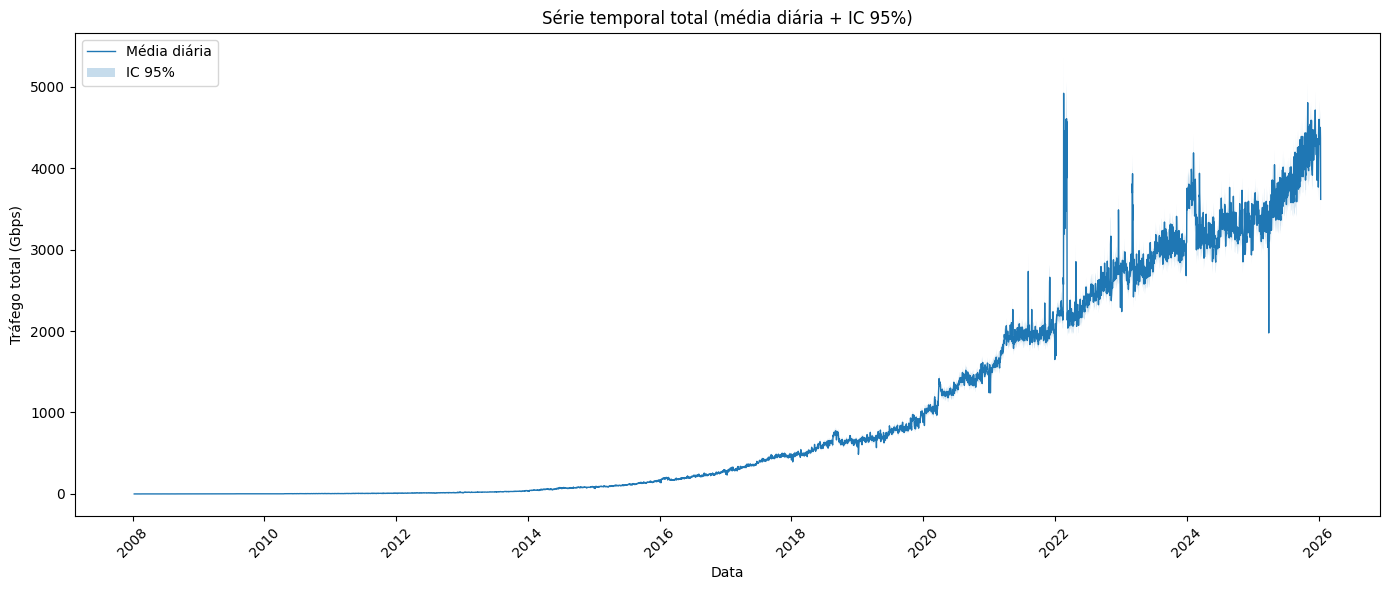

In [72]:
plt.figure(figsize=(14, 6))

plt.plot(
    media_diaria["data"],
    media_diaria["media_gbps"],
    label="Média diária",
    linewidth=1
)

plt.fill_between(
    media_diaria["data"],
    media_diaria["ci_lower"],
    media_diaria["ci_upper"],
    alpha=0.25,
    label="IC 95%"
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal total (média diária + IC 95%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

O uso da média diária reduz o ruído de curtíssimo prazo e facilita a visualização da tendência de longo prazo.

O intervalo de confiança de 95% resume a variabilidade intra-dia:

- faixas mais estreitas sugerem maior estabilidade;
- faixas mais largas sugerem maior dispersão das medições ao longo do dia.

## 14. Média diária suavizada (opcional)

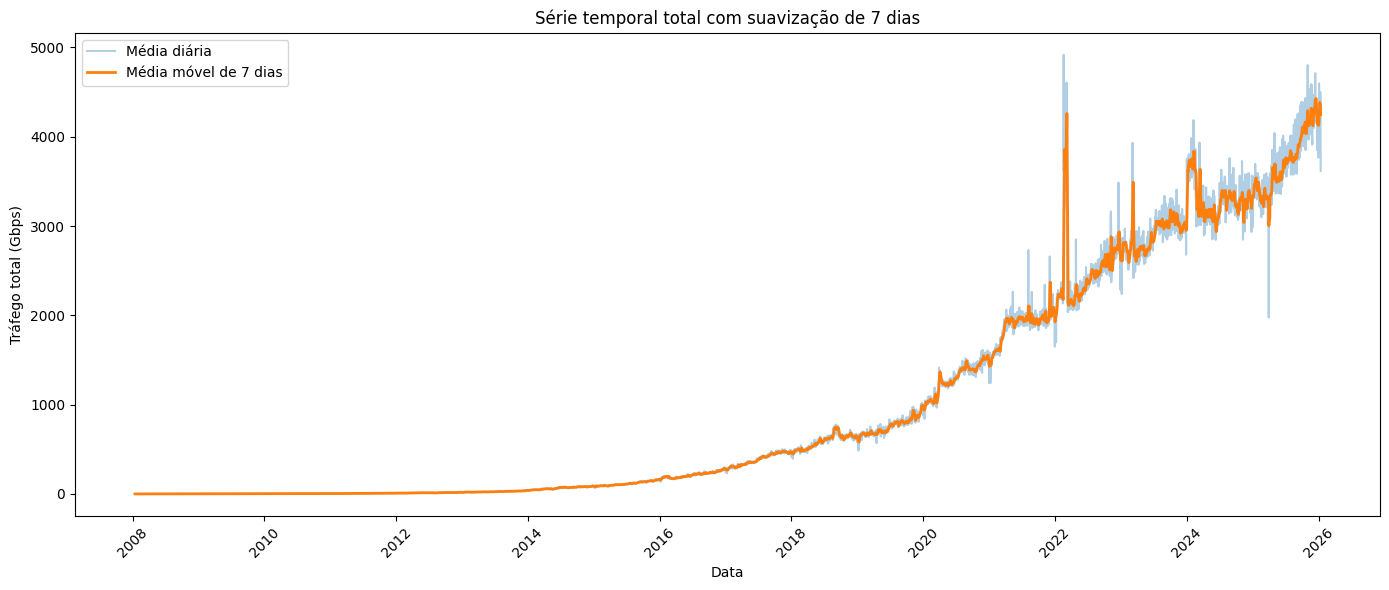

In [73]:
media_diaria["media_movel_7d"] = media_diaria["media_gbps"].rolling(7).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    media_diaria["data"],
    media_diaria["media_gbps"],
    alpha=0.35,
    label="Média diária"
)

plt.plot(
    media_diaria["data"],
    media_diaria["media_movel_7d"],
    linewidth=2,
    label="Média móvel de 7 dias"
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal total com suavização de 7 dias")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

A média móvel de 7 dias ajuda a destacar a tendência geral da série, reduzindo oscilações diárias.

## 15. Evolução intra-anual com média diária em Gbps

In [74]:
df_plot = df_filtrado.copy()
df_plot["dia_ano"] = df_plot["datahora"].dt.dayofyear

media_intra_anual = (
    df_plot.groupby(["year", "dia_ano"])["total_gbps"]
    .mean()
    .reset_index()
)

media_intra_anual.head()

,year,dia_ano,total_gbps
0,2008,1,NaN
1,2008,2,NaN
2,2008,3,NaN
3,2008,4,NaN
4,2008,5,NaN


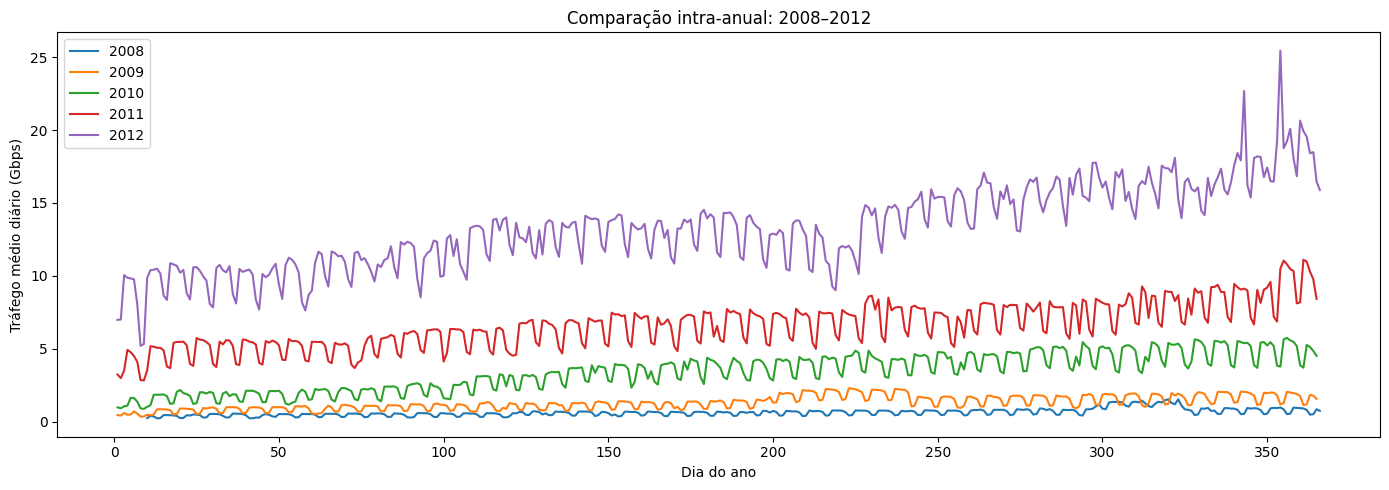

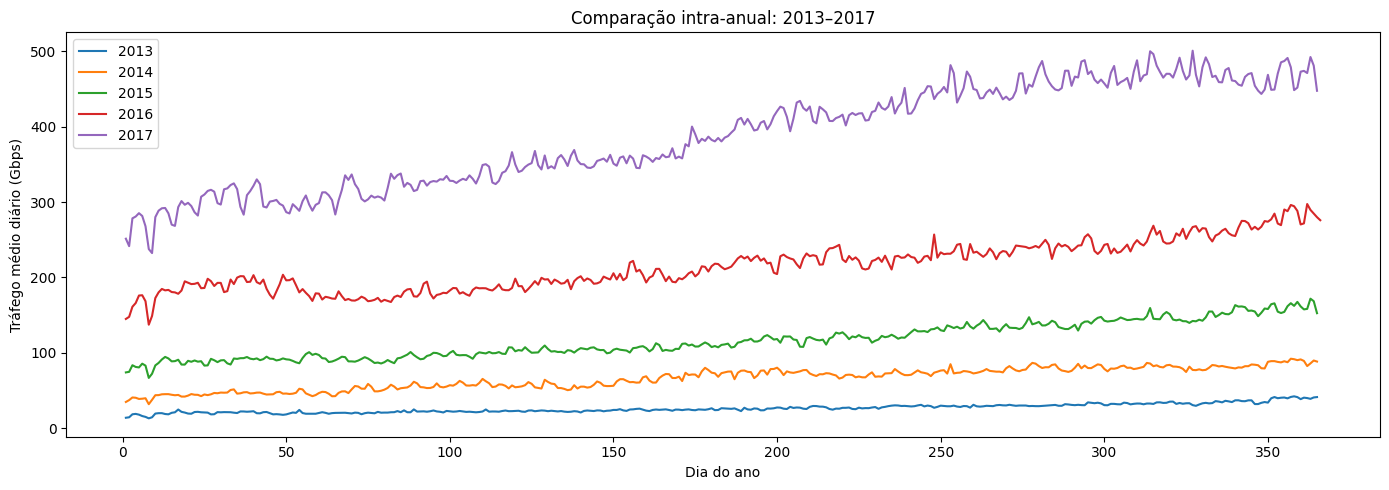

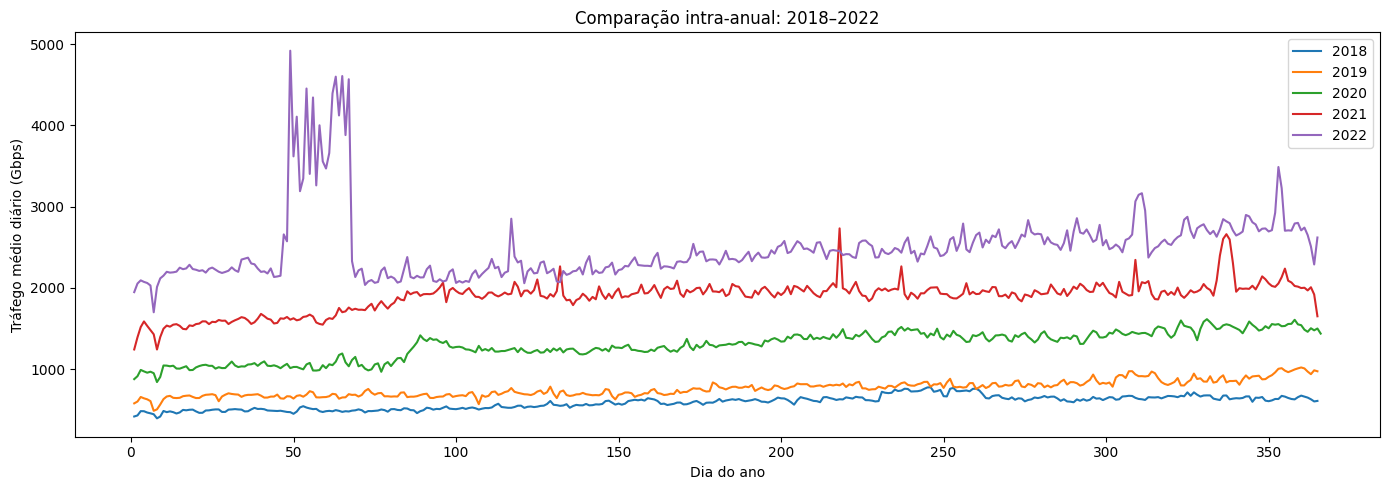

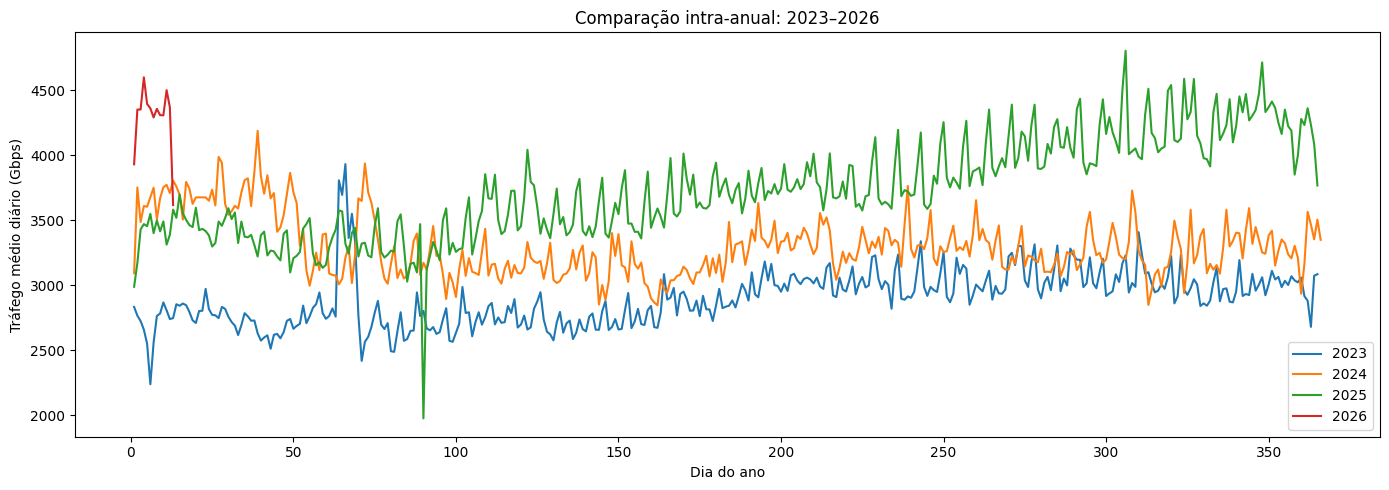

In [75]:
anos = sorted(media_intra_anual["year"].unique())
blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(14, 5))
    for ano in bloco:
        grupo = media_intra_anual[media_intra_anual["year"] == ano]
        plt.plot(grupo["dia_ano"], grupo["total_gbps"], label=str(ano))
    plt.xlabel("Dia do ano")
    plt.ylabel("Tráfego médio diário (Gbps)")
    plt.title(f"Comparação intra-anual: {bloco[0]}–{bloco[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretação

Esses gráficos permitem observar se há crescimento dentro do próprio ano, além de possíveis padrões sazonais ou mudanças de regime entre períodos.

## 16. Análise por dia da semana

Agora a análise passa a considerar o comportamento do tráfego total ao longo da semana, usando apenas os dados filtrados.

In [76]:
df_filtrado["weekday"] = df_filtrado["datahora"].dt.weekday

mapa_dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

resumo_weekday_total = (
    df_filtrado.groupby("weekday")["total_gbps"]
    .mean()
    .reset_index(name="media_total_gbps")
)

resumo_weekday_total["dia"] = resumo_weekday_total["weekday"].map(mapa_dias)
resumo_weekday_total["media_total_gbps"] = resumo_weekday_total["media_total_gbps"].round(3)

resumo_weekday_total

,weekday,media_total_gbps,dia
0,0,988.636,Seg
1,1,980.817,Ter
2,2,982.819,Qua
3,3,987.595,Qui
4,4,981.509,Sex
5,5,985.606,Sáb
6,6,1000.453,Dom


### Observação metodológica

A média agregada de todos os anos pode ser enviesada, porque os anos mais recentes têm nível de tráfego muito maior que os anos antigos. Por isso, além do resumo geral, também é útil comparar o padrão semanal por blocos temporais.

## 17. Padrão semanal por blocos de anos

In [77]:
for bloco in [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]:
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")
    media["dia"] = media["weekday"].map(mapa_dias)
    media["media_total_gbps"] = media["media_total_gbps"].round(3)

    print(f"\nPeríodo {bloco}:")
    print(media[["weekday", "dia", "media_total_gbps"]])


Período (2008, 2012):
   weekday  dia  media_total_gbps
0        0  Seg             4.160
1        1  Ter             5.430
2        2  Qua             5.430
3        3  Qui             5.402
4        4  Sex             5.366
5        5  Sáb             5.277
6        6  Dom             4.326

Período (2013, 2017):
   weekday  dia  media_total_gbps
0        0  Seg           159.877
1        1  Ter           160.722
2        2  Qua           161.500
3        3  Qui           162.075
4        4  Sex           162.672
5        5  Sáb           163.739
6        6  Dom           162.505

Período (2018, 2022):
   weekday  dia  media_total_gbps
0        0  Seg          1398.496
1        1  Ter          1394.796
2        2  Qua          1400.202
3        3  Qui          1393.564
4        4  Sex          1412.419
5        5  Sáb          1404.211
6        6  Dom          1400.817

Período (2023, 2026):
   weekday  dia  media_total_gbps
0        0  Seg          3328.940
1        1  Ter         

## 18. Plot do padrão semanal por bloco temporal

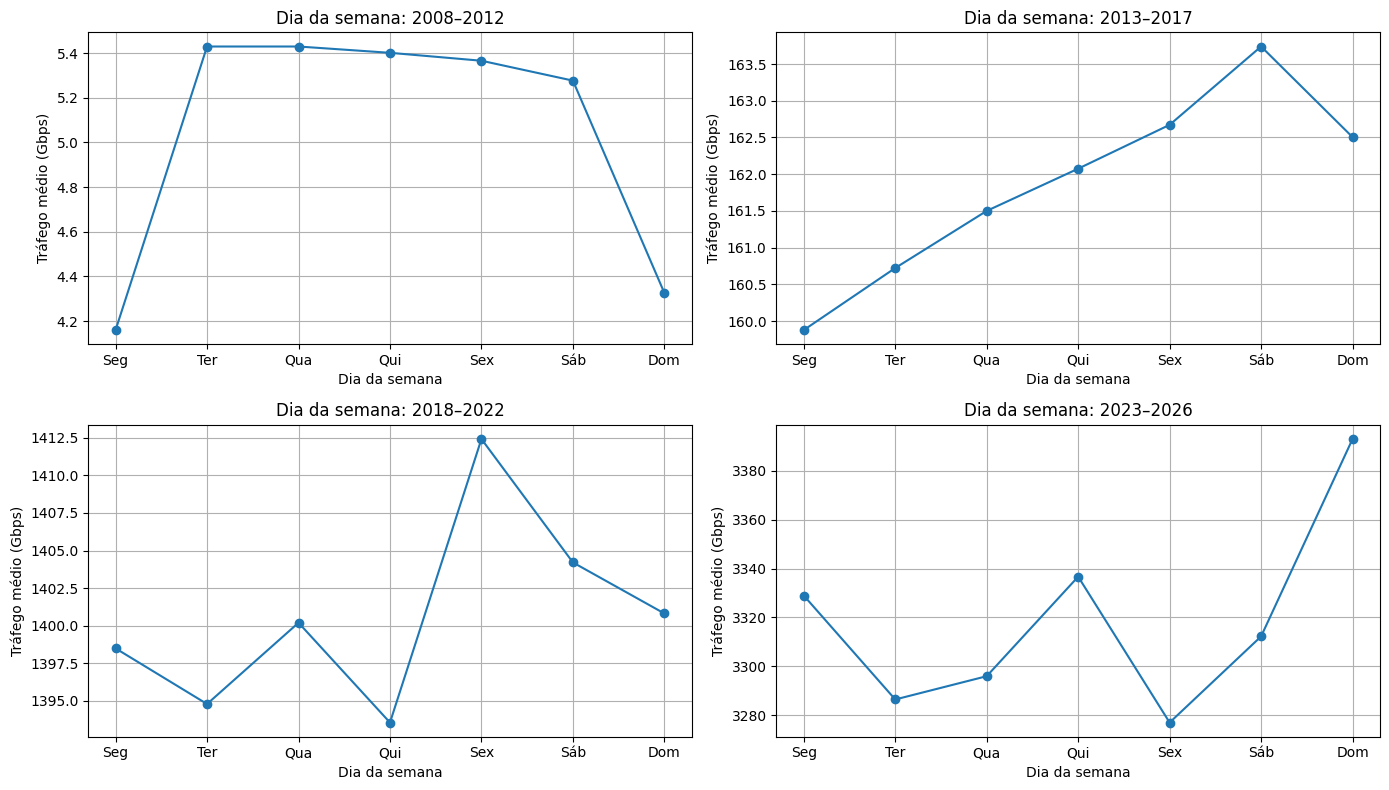

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

for ax, bloco in zip(axes, periodos):
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")

    ax.plot(media["weekday"], media["media_total_gbps"], marker="o")
    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"Dia da semana: {bloco[0]}–{bloco[1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Tráfego médio (Gbps)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretação

A análise por dia da semana permite verificar se o tráfego é maior em dias úteis ou em fins de semana, além de identificar mudanças de comportamento ao longo do tempo.

Em estudos anteriores deste conjunto de dados, observou-se uma transição de um padrão mais associado a dias úteis para um padrão mais uniforme e, nos anos mais recentes, com domingo relativamente mais forte.

## 19. Comparação entre dias úteis e fim de semana

Nesta etapa, a semana é resumida em dois grupos:

- **dias úteis**: segunda a sexta;
- **fim de semana**: sábado e domingo.

In [79]:
df_filtrado["is_weekend"] = df_filtrado["weekday"] >= 5

comparacao_weekend = (
    df_filtrado.groupby(["year", "is_weekend"])["total_gbps"]
    .mean()
    .reset_index()
)

comparacao_weekend["grupo"] = comparacao_weekend["is_weekend"].map({
    False: "dias_uteis",
    True: "fim_de_semana"
})

comparacao_weekend_pivot = comparacao_weekend.pivot(
    index="year",
    columns="grupo",
    values="total_gbps"
)

comparacao_weekend_pivot["razao_fim_semana_sobre_uteis"] = (
    comparacao_weekend_pivot["fim_de_semana"] /
    comparacao_weekend_pivot["dias_uteis"]
)

comparacao_weekend_pivot = comparacao_weekend_pivot.round(3)

comparacao_weekend_pivot

grupo,dias_uteis,fim_de_semana,razao_fim_semana_sobre_uteis
year,,,
2008,0.665,0.547,0.822
2009,1.366,1.130,0.828
2010,3.520,3.118,0.886
2011,6.754,6.169,0.913
2012,13.389,12.902,0.964
2013,26.354,26.569,1.008
2014,65.378,67.362,1.030
2015,115.913,116.954,1.009
2016,214.733,214.420,0.999


## 20. Plot da razão fim de semana / dias úteis

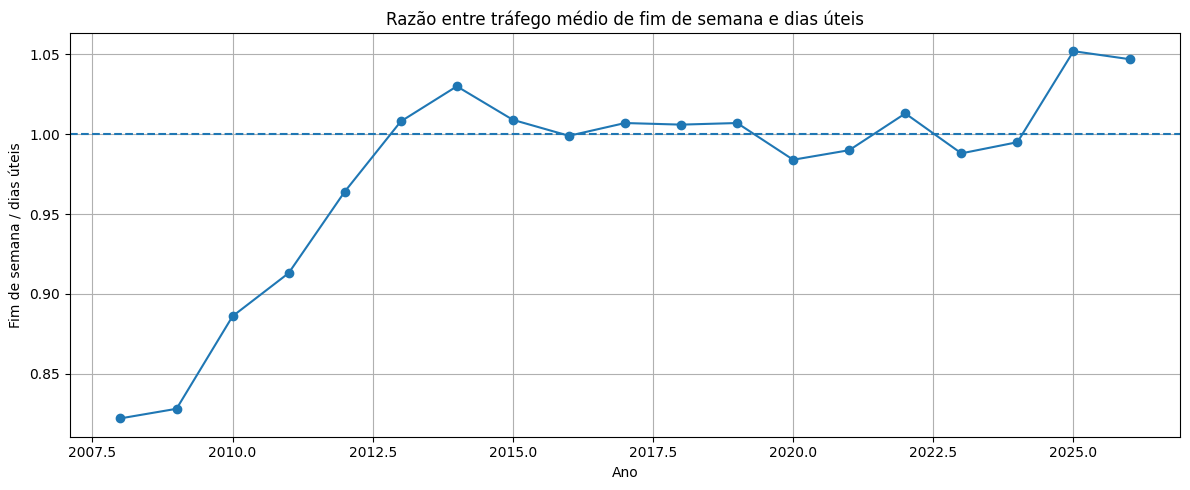

In [80]:
plt.figure(figsize=(12, 5))
plt.plot(
    comparacao_weekend_pivot.index,
    comparacao_weekend_pivot["razao_fim_semana_sobre_uteis"],
    marker="o"
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Ano")
plt.ylabel("Fim de semana / dias úteis")
plt.title("Razão entre tráfego médio de fim de semana e dias úteis")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretação

Essa razão resume o padrão semanal em uma única métrica:

- valores **abaixo de 1** indicam maior tráfego em dias úteis;
- valores **próximos de 1** indicam uniformização do padrão semanal;
- valores **acima de 1** sugerem maior intensidade relativa de tráfego no fim de semana.

Essa análise é útil para detectar mudanças estruturais no perfil de uso da rede.

## 21. Salvando os resumos de weekday e fim de semana

In [81]:
resumo_weekday_total.to_csv(arquivo_weekday_csv, index=False)
comparacao_weekend_pivot.to_csv(arquivo_weekend_csv)

print("Resumo por dia da semana salvo em:", arquivo_weekday_csv)
print("Comparação dias úteis vs fim de semana salva em:", arquivo_weekend_csv)

Resumo por dia da semana salvo em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/resumo_weekday_gbps.csv
Comparação dias úteis vs fim de semana salva em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/comparacao_weekend_gbps.csv


## 22. Análise complementar de picos de tráfego

Além das médias diárias, esta seção analisa os **picos de tráfego**. A ideia é complementar a visão do comportamento típico da rede com uma visão dos momentos de maior demanda.

Nesta etapa, o **pico diário** é definido como o **valor máximo diário** de `total_gbps`. Também é calculado o **percentil 95 diário**, útil como medida robusta de alta utilização.

In [ ]:
df_picos = df_filtrado.copy()
df_picos["data"] = df_picos["datahora"].dt.floor("D")

picos_diarios = (
    df_picos.groupby("data")["total_gbps"]
    .agg(
        pico_max_gbps="max",
        pico_p95_gbps=lambda x: x.quantile(0.95),
        media_gbps="mean",
        desvio_gbps="std",
        n_obs="count"
    )
    .reset_index()
)

picos_diarios["ano"] = picos_diarios["data"].dt.year
picos_diarios["weekday"] = picos_diarios["data"].dt.weekday
picos_diarios["is_weekend"] = picos_diarios["weekday"] >= 5
picos_diarios["dia_ano"] = picos_diarios["data"].dt.dayofyear
picos_diarios["fator_pico_sobre_media"] = (
    picos_diarios["pico_max_gbps"] / picos_diarios["media_gbps"]
)

picos_diarios.head()

## 23. Resumo anual dos picos

O resumo abaixo permite comparar a evolução dos níveis máximos de utilização da rede ao longo dos anos.

In [ ]:
resumo_picos = (
    picos_diarios.groupby("ano")
    .agg(
        media_pico_max_gbps=("pico_max_gbps", "mean"),
        mediana_pico_max_gbps=("pico_max_gbps", "median"),
        p95_dos_picos_max_gbps=("pico_max_gbps", lambda x: x.quantile(0.95)),
        media_pico_p95_gbps=("pico_p95_gbps", "mean"),
        media_fator_pico_sobre_media=("fator_pico_sobre_media", "mean")
    )
    .round(3)
)

resumo_picos

## 24. Série temporal dos picos diários

O gráfico a seguir mostra a evolução do pico máximo diário e do percentil 95 diário ao longo do tempo.

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    picos_diarios["data"],
    picos_diarios["pico_max_gbps"],
    label="Pico diário (máximo)",
    linewidth=0.9
)

plt.plot(
    picos_diarios["data"],
    picos_diarios["pico_p95_gbps"],
    label="P95 diário",
    linewidth=1.2
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal dos picos diários")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

Os picos diários tendem a ser mais voláteis do que as médias diárias, destacando momentos de maior pressão sobre a infraestrutura. A comparação entre o máximo diário e o percentil 95 ajuda a distinguir variações sistemáticas de eventos extremos isolados.

## 25. Comparação entre média diária e pico diário

In [ ]:
comparacao_media_pico = picos_diarios[["data", "media_gbps", "pico_max_gbps", "pico_p95_gbps", "fator_pico_sobre_media"]].copy()
comparacao_media_pico.head()

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparacao_media_pico["data"],
    comparacao_media_pico["media_gbps"],
    label="Média diária",
    linewidth=1
)

plt.plot(
    comparacao_media_pico["data"],
    comparacao_media_pico["pico_max_gbps"],
    label="Pico diário (máximo)",
    linewidth=0.9,
    alpha=0.8
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Comparação entre média diária e pico diário")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 26. Evolução intra-anual dos picos diários

In [ ]:
pico_intra_anual = (
    picos_diarios.groupby(["ano", "dia_ano"])["pico_max_gbps"]
    .mean()
    .reset_index()
)

pico_intra_anual.head()

In [ ]:
anos_pico = sorted(pico_intra_anual["ano"].unique())
blocos_pico = [anos_pico[i:i+5] for i in range(0, len(anos_pico), 5)]

for bloco in blocos_pico:
    plt.figure(figsize=(14, 5))

    for ano in bloco:
        df_temp = pico_intra_anual[pico_intra_anual["ano"] == ano]
        plt.plot(df_temp["dia_ano"], df_temp["pico_max_gbps"], label=str(ano), linewidth=1)

    plt.xlabel("Dia do ano")
    plt.ylabel("Pico diário (Gbps)")
    plt.title(f"Evolução intra-anual dos picos: {bloco[0]}–{bloco[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 27. Picos por dia da semana

Aqui a agregação é feita a partir do **pico diário**, e não da média de todas as observações de 5 em 5 minutos.

In [ ]:
resumo_weekday_picos = (
    picos_diarios.groupby("weekday")
    .agg(
        media_pico_max_gbps=("pico_max_gbps", "mean"),
        media_pico_p95_gbps=("pico_p95_gbps", "mean"),
        media_fator_pico_sobre_media=("fator_pico_sobre_media", "mean")
    )
    .reset_index()
)

resumo_weekday_picos["dia"] = resumo_weekday_picos["weekday"].map(mapa_dias)
resumo_weekday_picos = resumo_weekday_picos.round(3)

resumo_weekday_picos

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(resumo_weekday_picos["weekday"], resumo_weekday_picos["media_pico_max_gbps"], marker="o", label="Pico diário médio")
plt.plot(resumo_weekday_picos["weekday"], resumo_weekday_picos["media_pico_p95_gbps"], marker="o", label="P95 diário médio")
plt.xticks(range(7), [mapa_dias[i] for i in range(7)])
plt.xlabel("Dia da semana")
plt.ylabel("Tráfego (Gbps)")
plt.title("Picos de tráfego por dia da semana")
plt.legend()
plt.tight_layout()
plt.show()

## 28. Picos por dia da semana em blocos de anos

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

for ax, bloco in zip(axes, periodos):
    df_temp = picos_diarios[
        (picos_diarios["ano"] >= bloco[0]) &
        (picos_diarios["ano"] <= bloco[1])
    ]

    media = (
        df_temp.groupby("weekday")["pico_max_gbps"]
        .mean()
        .reset_index(name="media_pico_max_gbps")
    )

    ax.plot(media["weekday"], media["media_pico_max_gbps"], marker="o")
    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"Picos por dia da semana: {bloco[0]}–{bloco[1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Pico diário médio (Gbps)")
    ax.grid(True)

plt.tight_layout()
plt.show()

## 29. Comparação entre dias úteis e fim de semana para os picos

In [ ]:
comparacao_weekend_picos = (
    picos_diarios.groupby(["ano", "is_weekend"])["pico_max_gbps"]
    .mean()
    .reset_index()
)

comparacao_weekend_picos["grupo"] = comparacao_weekend_picos["is_weekend"].map({
    False: "dias_uteis",
    True: "fim_de_semana"
})

comparacao_weekend_picos_pivot = comparacao_weekend_picos.pivot(
    index="ano",
    columns="grupo",
    values="pico_max_gbps"
)

comparacao_weekend_picos_pivot["razao_fim_semana_sobre_uteis"] = (
    comparacao_weekend_picos_pivot["fim_de_semana"] /
    comparacao_weekend_picos_pivot["dias_uteis"]
)

comparacao_weekend_picos_pivot = comparacao_weekend_picos_pivot.round(3)
comparacao_weekend_picos_pivot

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    comparacao_weekend_picos_pivot.index,
    comparacao_weekend_picos_pivot["razao_fim_semana_sobre_uteis"],
    marker="o"
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Ano")
plt.ylabel("Fim de semana / dias úteis")
plt.title("Razão entre pico diário médio de fim de semana e dias úteis")
plt.grid(True)
plt.tight_layout()
plt.show()

## 30. Distribuição dos picos diários

In [ ]:
plt.figure(figsize=(12, 5))
plt.hist(picos_diarios["pico_max_gbps"], bins=50)
plt.xlabel("Pico diário (Gbps)")
plt.ylabel("Frequência")
plt.title("Distribuição dos picos diários")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(picos_diarios["pico_max_gbps"].dropna(), vert=False)
plt.xlabel("Pico diário (Gbps)")
plt.title("Boxplot dos picos diários")
plt.tight_layout()
plt.show()

## 31. Padrão intra-dia de alta utilização

Além do pico diário, também é possível observar o horário em que a rede tende a operar sob alta carga. Para isso, usa-se o **percentil 95 do tráfego por horário do dia**, agregando todas as observações disponíveis.

In [ ]:
df_picos_intradia = df_filtrado.copy()
df_picos_intradia["hora_decimal"] = (
    df_picos_intradia["datahora"].dt.hour +
    df_picos_intradia["datahora"].dt.minute / 60
)

pico_por_hora = (
    df_picos_intradia.groupby("hora_decimal")["total_gbps"]
    .agg(
        p95_gbps=lambda x: x.quantile(0.95),
        max_gbps="max",
        media_gbps="mean"
    )
    .reset_index()
)

pico_por_hora.head()

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(pico_por_hora["hora_decimal"], pico_por_hora["media_gbps"], label="Média", linewidth=1)
plt.plot(pico_por_hora["hora_decimal"], pico_por_hora["p95_gbps"], label="P95", linewidth=2)
plt.plot(pico_por_hora["hora_decimal"], pico_por_hora["max_gbps"], label="Máximo observado", linewidth=1, alpha=0.8)
plt.xlabel("Hora do dia")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Padrão intra-dia de alta utilização")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()

## 32. Salvando os resumos de picos

In [ ]:
arquivo_resumo_picos_csv = saida_dir / "resumo_picos_diarios.csv"
arquivo_weekday_picos_csv = saida_dir / "resumo_weekday_picos.csv"
arquivo_weekend_picos_csv = saida_dir / "comparacao_weekend_picos.csv"

resumo_picos.to_csv(arquivo_resumo_picos_csv)
resumo_weekday_picos.to_csv(arquivo_weekday_picos_csv, index=False)
comparacao_weekend_picos_pivot.to_csv(arquivo_weekend_picos_csv)

print("Resumo anual de picos salvo em:", arquivo_resumo_picos_csv)
print("Resumo de picos por dia da semana salvo em:", arquivo_weekday_picos_csv)
print("Comparação fim de semana vs dias úteis (picos) salva em:", arquivo_weekend_picos_csv)

# Conclusões preliminares

Com base nos dados filtrados por completude e analisados apenas em termos de tráfego total, é possível observar:

1. crescimento estrutural do tráfego ao longo do tempo;
2. diferenças relevantes entre anos no nível médio de tráfego;
3. utilidade da média diária para reduzir ruído e destacar tendência;
4. presença de variabilidade intra-dia, resumida pelo intervalo de confiança;
5. indícios de variação intra-anual em diferentes períodos;
6. possibilidade de mudança estrutural no padrão semanal, comparando dias úteis e fim de semana.

# Próximos passos

Como continuidade, podem ser desenvolvidas as seguintes análises:

- comparação formal entre anos usando testes ou modelos estatísticos;
- decomposição da série em tendência e sazonalidade;
- análise intra-semana e intra-dia com mais detalhe;
- identificação de pontos de mudança estrutural;
- tratamento de valores suspeitos ou anômalos, se necessário.

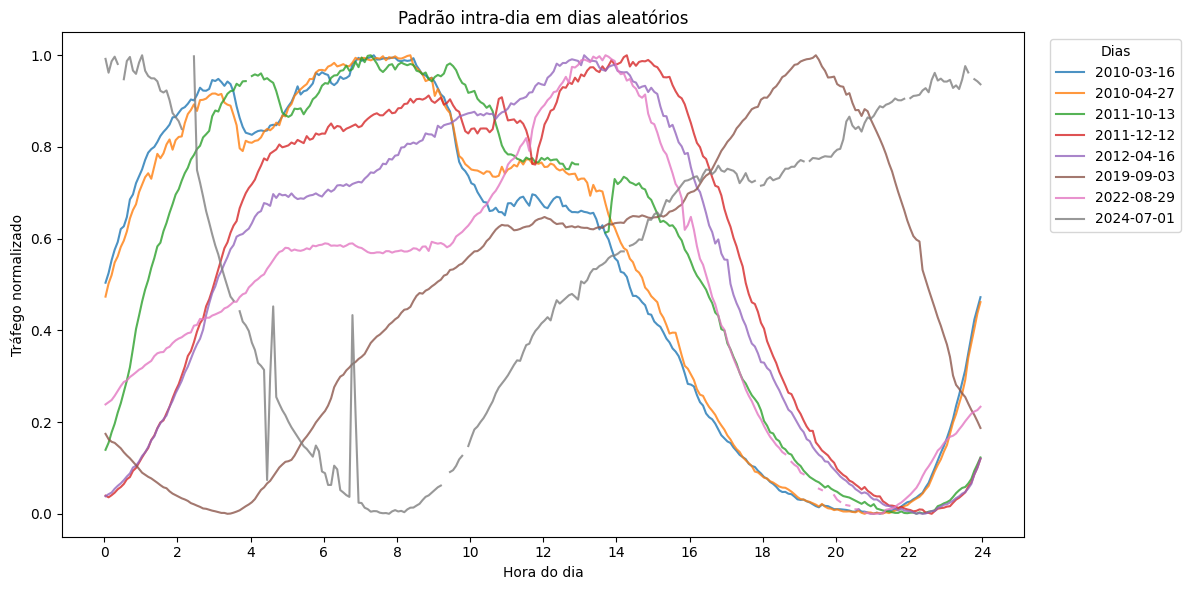

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# cópia da base
df_intradia = df_filtrado.copy()

# criar coluna de data e horário
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["hora_min"] = df_intradia["datahora"].dt.hour * 60 + df_intradia["datahora"].dt.minute

# manter apenas dias completos (288 medições de 5 em 5 min)
contagem_por_dia = df_intradia.groupby("data").size()
dias_completos = contagem_por_dia[contagem_por_dia == 288].index

df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# sortear alguns dias aleatórios
np.random.seed(42)
n_dias = 8
dias_sorteados = np.random.choice(df_intradia["data"].unique(), size=n_dias, replace=False)

df_amostra = df_intradia[df_intradia["data"].isin(dias_sorteados)].copy()

# normalizar cada dia: (x - min) / (max - min)
def normalizar_dia(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_amostra["total_norm"] = df_amostra.groupby("data")["total_gbps"].transform(normalizar_dia)

# eixo x em horas
df_amostra["hora_decimal"] = (
    df_amostra["datahora"].dt.hour +
    df_amostra["datahora"].dt.minute / 60
)

# plot
plt.figure(figsize=(12, 6))

for dia, grupo in df_amostra.groupby("data"):
    plt.plot(grupo["hora_decimal"], grupo["total_norm"], alpha=0.8, label=str(dia))

plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado")
plt.title("Padrão intra-dia em dias aleatórios")
plt.xticks(range(0, 25, 2))
plt.legend(title="Dias", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

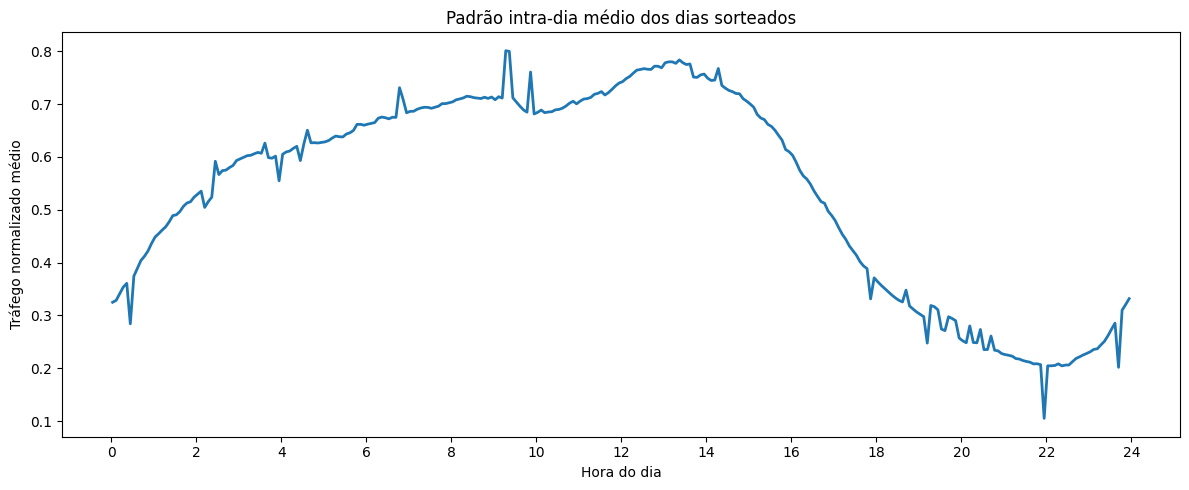

In [83]:
media_intradia = (
    df_amostra.groupby("hora_decimal")["total_norm"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(media_intradia["hora_decimal"], media_intradia["total_norm"], linewidth=2)
plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado médio")
plt.title("Padrão intra-dia médio dos dias sorteados")
plt.xticks(range(0, 25, 2))
plt.tight_layout()
plt.show()

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_intradia = df_filtrado.copy()

# criar variáveis
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["hora_decimal"] = (
    df_intradia["datahora"].dt.hour +
    df_intradia["datahora"].dt.minute / 60
)

# manter apenas dias completos (288 pontos)
contagem = df_intradia.groupby("data").size()
dias_completos = contagem[contagem == 288].index

df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# -------- NORMALIZAÇÃO POR DIA --------
def normalizar(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_intradia["total_norm"] = df_intradia.groupby("data")["total_gbps"].transform(normalizar)

# -------- AGREGAÇÃO INTRA-DIA --------
intradia_stats = (
    df_intradia.groupby("hora_decimal")["total_norm"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# intervalo de confiança 95%
intradia_stats["ci_lower"] = intradia_stats["mean"] - 1.96 * (
    intradia_stats["std"] / np.sqrt(intradia_stats["count"])
)

intradia_stats["ci_upper"] = intradia_stats["mean"] + 1.96 * (
    intradia_stats["std"] / np.sqrt(intradia_stats["count"])
)

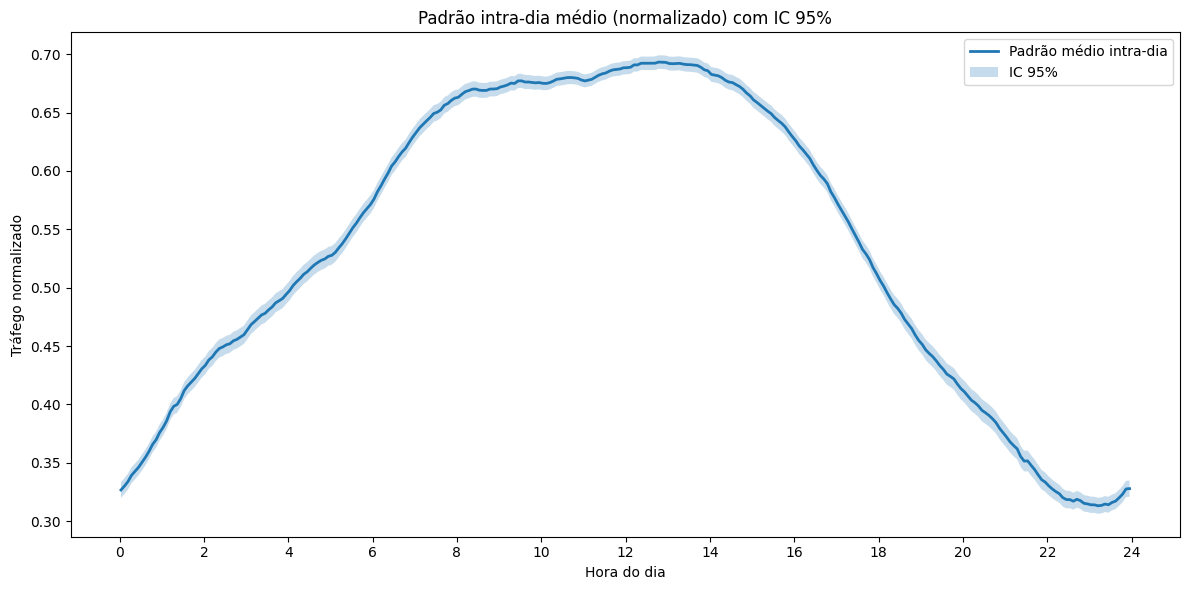

In [85]:
plt.figure(figsize=(12, 6))

plt.plot(
    intradia_stats["hora_decimal"],
    intradia_stats["mean"],
    label="Padrão médio intra-dia",
    linewidth=2
)

plt.fill_between(
    intradia_stats["hora_decimal"],
    intradia_stats["ci_lower"],
    intradia_stats["ci_upper"],
    alpha=0.25,
    label="IC 95%"
)

plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado")
plt.title("Padrão intra-dia médio (normalizado) com IC 95%")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_intradia = df_filtrado.copy()

# variáveis auxiliares
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["year"] = df_intradia["datahora"].dt.year
df_intradia["hora_decimal"] = (
    df_intradia["datahora"].dt.hour +
    df_intradia["datahora"].dt.minute / 60
)

# manter apenas dias completos
contagem = df_intradia.groupby("data").size()
dias_completos = contagem[contagem == 288].index
df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# normalização por dia
def normalizar(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_intradia["total_norm"] = df_intradia.groupby("data")["total_gbps"].transform(normalizar)

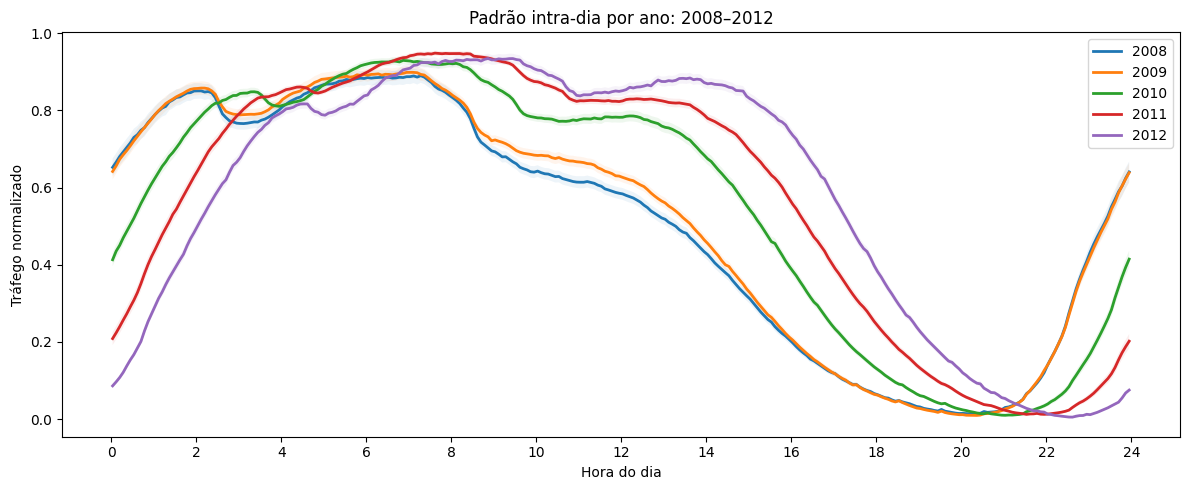

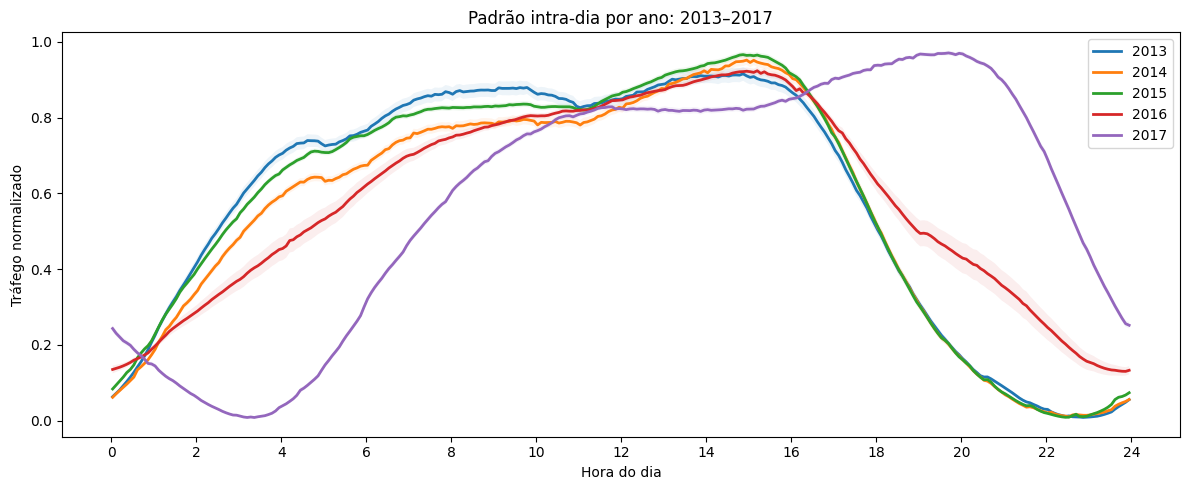

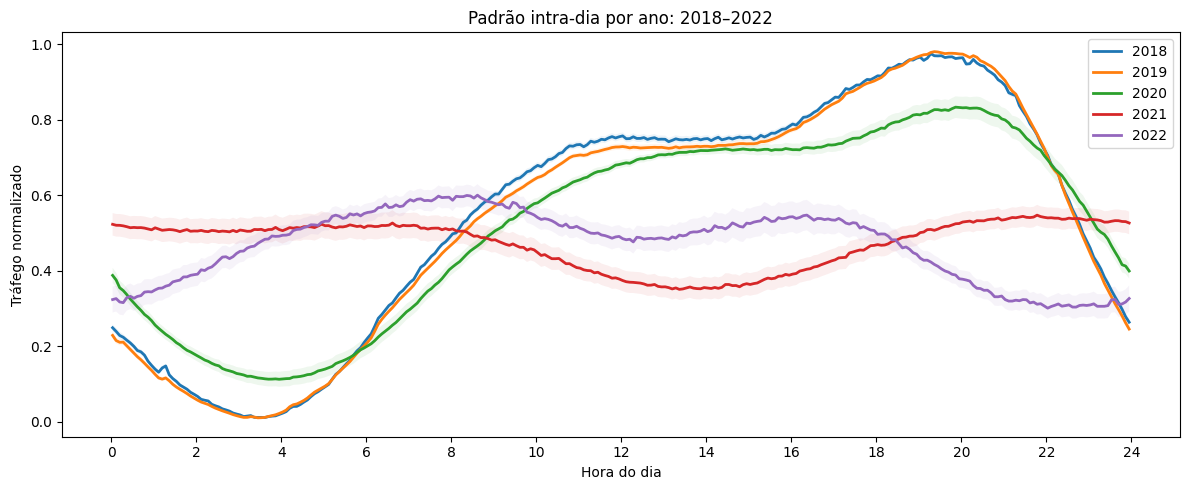

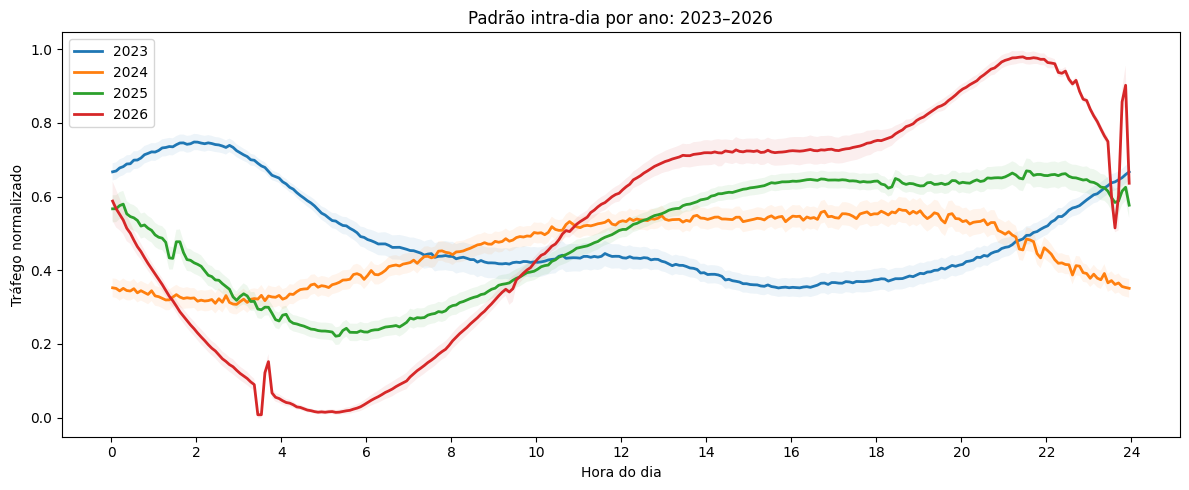

In [ ]:
anos = sorted(df_intradia["year"].unique())


blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(12, 5))

    for ano in bloco:
        df_ano = df_intradia[df_intradia["year"] == ano]

        stats = (
            df_ano.groupby("hora_decimal")["total_norm"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        # IC
        stats["ci_lower"] = stats["mean"] - 1.96 * (stats["std"] / np.sqrt(stats["count"]))
        stats["ci_upper"] = stats["mean"] + 1.96 * (stats["std"] / np.sqrt(stats["count"]))

        # linha principal
        plt.plot(
            stats["hora_decimal"],
            stats["mean"],
            label=str(ano),
            linewidth=2
        )

        # IC (opcional mais leve)
        plt.fill_between(
            stats["hora_decimal"],
            stats["ci_lower"],
            stats["ci_upper"],
            alpha=0.08
        )

    plt.xlabel("Hora do dia")
    plt.ylabel("Tráfego normalizado")
    plt.title(f"Padrão intra-dia por ano: {bloco[0]}–{bloco[-1]}")
    plt.xticks(range(0, 25, 2))
    plt.legend()
    plt.tight_layout()
    plt.show()

# Interpretação dos padrões intra-diários

## Evolução do comportamento ao longo do tempo

A análise dos perfis intra-diários revela uma transformação significativa no comportamento do tráfego agregado do IX ao longo dos anos.

### 2008–2012: padrão concentrado e antecipado

Nos anos iniciais, observa-se:

- pico de tráfego nas primeiras horas do dia (aproximadamente entre 6h e 8h);
- queda progressiva ao longo do dia;
- valores mínimos durante a noite.

Esse comportamento é consistente com um padrão de uso predominantemente corporativo, no qual o tráfego está associado a atividades em horário comercial.

---

### 2013–2017: período de transição

Nesse intervalo, verifica-se:

- deslocamento gradual do pico para o meio do dia;
- aumento da largura da curva de tráfego;
- redução da diferença entre períodos de alta e baixa utilização.

Esse padrão sugere uma transição no perfil de uso da rede, possivelmente associada à expansão do acesso residencial e ao aumento do consumo de conteúdo online.

---

### 2018–2022: predominância de consumo digital

A partir de 2018, observa-se uma mudança mais acentuada:

- pico de tráfego deslocado para o período noturno (aproximadamente entre 18h e 21h);
- curva mais "achatada", indicando uso mais distribuído ao longo do dia;
- menor variação relativa entre diferentes horários.

Esse comportamento é compatível com o crescimento de aplicações como streaming, redes sociais e uso intensivo da internet em dispositivos móveis.

---

### 2023–2026: uso contínuo da rede

Nos anos mais recentes:

- o tráfego apresenta maior uniformidade ao longo do dia;
- a diferença entre períodos de pico e vale é reduzida;
- o sistema opera próximo de níveis elevados durante a maior parte do tempo.

Esse padrão indica que a internet passou a ser utilizada como infraestrutura contínua, e não mais apenas em horários específicos.

---

## Mudança estrutural no perfil de uso

De forma geral, os resultados evidenciam uma mudança estrutural no comportamento da rede:

- inicialmente dominada por uso corporativo;
- posteriormente caracterizada por uma fase de transição;
- e, por fim, marcada por consumo massivo e contínuo de conteúdo digital.

Essa transformação reflete mudanças tecnológicas e sociais, incluindo maior penetração da internet, crescimento do consumo de mídia online e alterações nos hábitos dos usuários.

---

## Estabilidade do formato intra-diário

Apesar da evolução observada, nota-se que:

- o padrão intra-diário mantém uma forma consistente;
- o que se altera ao longo do tempo é principalmente o nível (escala) e o posicionamento do pico.

Isso sugere que o sistema apresenta:

- invariância de forma (shape);
- crescimento de escala (level).

---

## Qualidade dos dados e anomalias

Durante a análise, foram identificados alguns comportamentos atípicos, como:

- curvas com quedas abruptas próximas de zero;
- padrões inconsistentes em determinados anos (por exemplo, 2026).

Esses casos indicam possíveis problemas de medição ou dados incompletos, reforçando a importância da etapa de validação e filtragem da base antes da análise.

---

## Conclusão

A análise intra-diária mostra que:

- o comportamento do tráfego evoluiu significativamente ao longo dos anos;
- o pico de utilização foi deslocado para períodos mais tardios;
- o uso da rede tornou-se mais contínuo e distribuído ao longo do dia.

Esses resultados são consistentes com a transformação da internet em uma infraestrutura essencial para múltiplos tipos de uso, incluindo entretenimento, comunicação e trabalho remoto.

## Padrão intra-dia — principais achados

- 2008–2012: pico pela manhã → uso mais corporativo  
- 2013–2017: transição → uso mais distribuído  
- 2018–2022: pico à noite → consumo digital (streaming, mobile)  
- 2023+: uso quase contínuo ao longo do dia  

👉 Mudança estrutural:
- de uso concentrado → uso massivo e distribuído  

👉 Padrão diário é estável (forma), mas cresce em escala  

⚠️ Há indícios de dados anômalos em alguns anos (ex: 2026)



A internet deixou de ter horário de uso — ela virou infraestrutura contínua.”